In [14]:
# Importar bibliotecas
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Carregando a base de dados
df = pd.read_csv('base/Valor_combustivel_Brasil_2020_2025.csv', sep=';')


C:\Users\WFerreira\AppData\Local\Temp\ipykernel_2012\3474830855.py:7: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('base/Valor_combustivel_Brasil_2020_2025.csv', sep=';')


In [15]:
#Tratando os dados da analise
#Extraindo o ano da coleta
df['Data da Coleta'] = pd.to_datetime(df['Data da Coleta'], errors='coerce')
df['Ano'] = df['Data da Coleta'].dt.year

#Tratando os valores de venda
df['Valor de Venda'] = pd.to_numeric(df['Valor de Venda'], errors='coerce')
#Subistituindo valores ausentes
media_valor = df['Valor de Venda'].mean()
df['Valor de Venda'] = df['Valor de Venda'].fillna(media_valor)

# Filtrar apenas gasolina e últimos 5 Data da Coletas
df = df[(df['Produto'] == 'GASOLINA') & (df['Ano'] >= 2020)]

#print(df.dtypes)


# Agrupar por região e Data da Coleta
df_grouped = df.groupby(['Regiao - Sigla', 'Ano'])['Valor de Venda'].mean().reset_index()

# Codificar regiao como números
df_grouped['Regiao_cod'] = df_grouped['Regiao - Sigla'].astype('category').cat.codes


In [ ]:
#3. Regressç-ão linear

X = df_grouped[['Regiao_cod', 'Ano']]
y = df_grouped['Valor de Venda']

# Dividir em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Treinando o modelo
model = LinearRegression()
model.fit(X_train, y_train)
# Prever
y_pred = model.predict(X_test)



In [17]:
#4. Avaliação do modelo
from sklearn.metrics import r2_score

print("R²:", r2_score(y_test, y_pred))


R²: -190138.52527642922


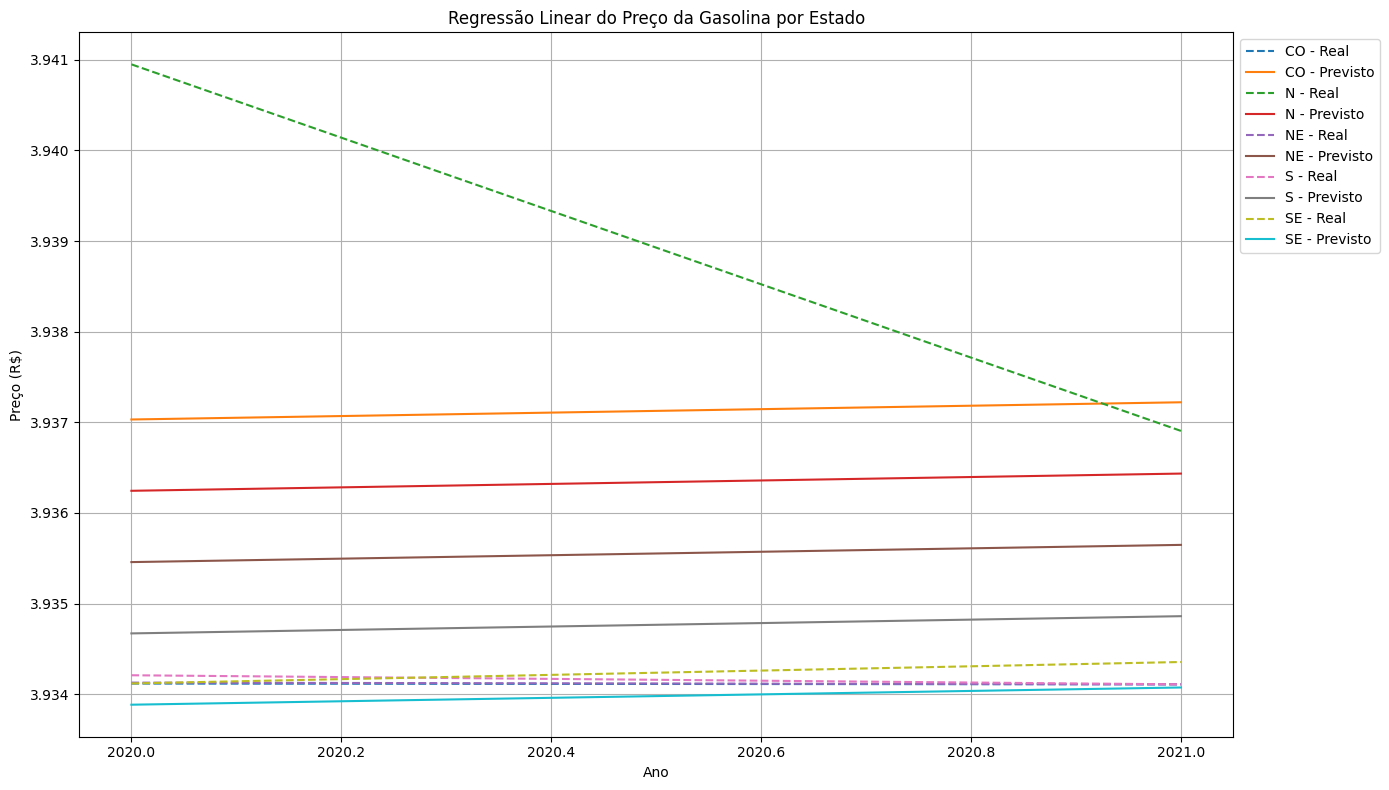

In [18]:
import matplotlib.pyplot as plt

# Prever para todos os dados
df_grouped['Preco_Previsto'] = model.predict(X)

# Lista de estados únicos
estados = df_grouped['Regiao - Sigla'].unique()

# Tamanho do gráfico
plt.figure(figsize=(14, 8))

# Plotar cada estado
for estado in estados:
    dados_estado = df_grouped[df_grouped['Regiao - Sigla'] == estado]
    
    # Preço real
    plt.plot(dados_estado['Ano'], dados_estado['Valor de Venda'], label=f'{estado} - Real', linestyle='--')
    
    # Preço previsto
    plt.plot(dados_estado['Ano'], dados_estado['Preco_Previsto'], label=f'{estado} - Previsto')

plt.title('Regressão Linear do Preço da Gasolina por Estado')
plt.xlabel('Ano')
plt.ylabel('Preço (R$)')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True)
plt.tight_layout()
plt.show()